# 01 — Prediction diagnostics on the headline 21-day models

**What this notebook does:** loads the predictions already in the DuckDB store and runs three diagnostic checks on them. No model fitting in this notebook — all fits already happened via `python -m price_model.cli run ...` and were persisted.

**Companion notebooks:**
- `00_pit_ablation_study.ipynb` — survivorship-bias quantification (legacy v2 panel)
- `03_headline_robustness.ipynb` — bootstrap CI / decile / time-split robustness
- `05_feature_exploration.ipynb` — feature distributions, correlations, fitted feature importance

**This notebook focuses on three questions about *how the predictions behave over time*** — questions a static comparison table can't answer.

| Section | Question it answers | Why it matters |
|---|---|---|
| **1. Apples-to-apples table** | Which model has the highest 21-day OOS IC on the 2025+ slice? | Quick scoreboard for current models in the store. |
| **2. Rolling 60-day IC** | Is the model's IC stable over time, or does it come from a few high-IC months? | Mean IC averages over time. A model with IC = +0.005 from `+0.005 every month` is fundamentally different from one with `+0.05, -0.04, +0.04, ...`. The bootstrap CI in notebook 03 can't distinguish them; this one can. |
| **3. Regime-conditional IC** | Does the model's edge depend on the volatility regime? | The README's Discussion argues that HP optimization is fragile to regime shift. This section gives the empirical evidence on a vol-split. |
| **4. Net-of-cost gross-vs-net Sharpe** | Which model produces the highest *net* Sharpe after 20 bp costs? | The README's gross-vs-net inversion (Claim 1 corollary) — the L1 regression wins on gross IC; the 36-month momentum factor wins on net Sharpe because of an 8× turnover differential. |

All diagnostics use **21-day forward excess return** as the target — matches the README headline horizon.


## 0. Setup


In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.stats import spearmanr

from price_model.data.loaders import load_panel
from price_model.eval.metrics import compare_models
from price_model.features.targets import add_forward_excess_return
from price_model.serving.store import PredictionStore

warnings.filterwarnings('ignore')
pl.Config(tbl_width_chars=200, tbl_cols=20)
plt.rcParams['figure.figsize'] = (12, 4)

# Models referenced in the README's headline 21-day comparison table.
HEADLINE_MODELS = [
    'lasso_elasso_pit_h21',                              # L1 regression, 9-feature
    'mom_504_factor_h21',                                # 24-month momentum
    'mom_756_factor_h21',                                # 36-month momentum
    'mom_378_factor_h21',                                # 18-month momentum
    'mom_12_1_factor_h21',                               # JT 12-1 canonical
    'ridge_pit_h21',                                     # Ridge 12-feature
    'lightgbm_kaggle_v3_curated_h21',                    # LightGBM default HPs
    'lightgbm_kaggle_v3_curated_h21_hp_pre20241231',     # LightGBM held-out Optuna
]

# Load realized 21-day forward excess returns on the PIT-corrected universe.
panel = load_panel(universe='sp500_pit', start='2017-01-01', pit_filter=True)
panel = add_forward_excess_return(panel, horizon_days=21)
realized = panel.select('date', 'ticker', pl.col('y').alias('realized'))
print(f'Panel loaded: {panel.height:,} rows, {panel["ticker"].n_unique()} tickers, '
      f'{panel["date"].min()} → {panel["date"].max()}')


$HOLX: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-25) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-25) (Yahoo error = "No data found, symbol may be delisted")
$HOLX: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-25) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-25) (Yahoo error = "No data found, symbol may be delisted")
$HOLX: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-25) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-25) (Yahoo error = "No data found, symbol may be delisted")
yfinance returned no data for HOLX after 3 attempts
$SEE: possibly delisted; no price data found  (1d 2026-04-09 -> 2026-06-25) (Yaho

Panel loaded: 1,119,386 rows, 599 tickers, 2017-01-03 → 2026-06-24


## 1. Apples-to-apples comparison table

**Question:** Which model has the highest 21-day OOS IC on the 2025+ slice?

**Why it matters:** quick scoreboard for the models currently in the prediction store. Should match the README's headline table; if it doesn't, the prediction store is out of sync with the README and needs re-running. Use this cell to validate that the headline ranking holds on your local data.


In [2]:
# Pull predictions for the headline models from the store.
store = PredictionStore(read_only=True)
ids = ", ".join(f"'{m}'" for m in HEADLINE_MODELS)
preds = store.query(f'''
    SELECT model_id, prediction_date AS date, ticker, prediction
    FROM predictions
    WHERE model_id IN ({ids})
''')
store.close()

# Restrict to 2025+ to match the README's eval slice.
preds_2025 = preds.filter(pl.col('date') >= pl.lit('2025-01-01').cast(pl.Date))
joined = preds_2025.join(realized, on=['date', 'ticker'], how='inner')
summary = compare_models(joined, horizon_days=21).sort(
    'information_coefficient', descending=True,
)
with pl.Config(tbl_width_chars=300, tbl_cols=20):
    print(summary)


shape: (8, 9)
┌─────────────────────────────────┬────────────────┬─────────┬─────────────────────────┬───────────┬──────────┬──────────┬──────────┬───────────────────┐
│ model_id                        ┆ n_observations ┆ n_dates ┆ information_coefficient ┆ ic_t_stat ┆ hit_rate ┆ mae      ┆ rmse     ┆ long_short_sharpe │
│ ---                             ┆ ---            ┆ ---     ┆ ---                     ┆ ---       ┆ ---      ┆ ---      ┆ ---      ┆ ---               │
│ str                             ┆ i64            ┆ i64     ┆ f64                     ┆ f64       ┆ f64      ┆ f64      ┆ f64      ┆ f64               │
╞═════════════════════════════════╪════════════════╪═════════╪═════════════════════════╪═══════════╪══════════╪══════════╪══════════╪═══════════════════╡
│ lasso_elasso_pit_h21            ┆ 156376         ┆ 348     ┆ 0.071013                ┆ 5.540894  ┆ 0.520444 ┆ 0.06399  ┆ 0.089712 ┆ 1.237054          │
│ mom_756_factor_h21              ┆ 156376         ┆ 348     ┆

## 2. Rolling 60-day IC — is the edge stable over time?

**Question:** Does the model's IC come from a stable signal or from alternating high-IC / low-IC regimes?

**Why it matters:** a model with mean IC = +0.03 from `+0.03 every month` is fundamentally different from one with `+0.06, +0.00, +0.06, +0.00, ...`. Both have the same mean. The bootstrap CI in notebook 03 averages over the eval period and can't distinguish them. This plot can.

**What good looks like:** the rolling-IC line is consistently above zero with small variance. **What bad looks like:** the line oscillates around zero with large variance — the average is masking instability.


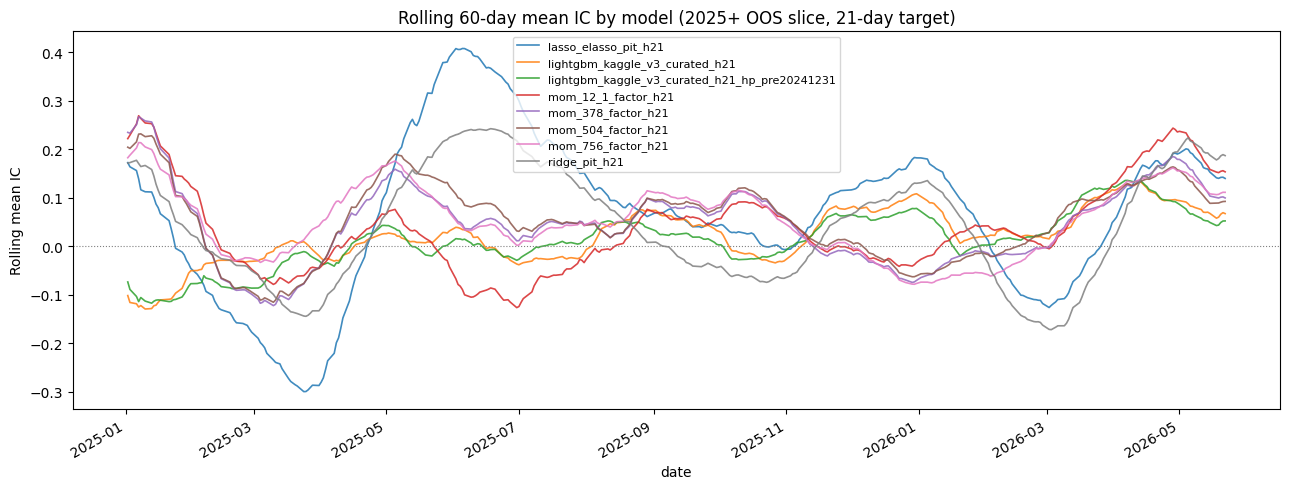

In [3]:
def per_date_ic(df: pl.DataFrame) -> pl.DataFrame:
    """Compute Spearman IC per (model_id, date)."""
    rows = []
    for (model_id, d), grp in df.group_by(['model_id', 'date']):
        sub = grp.drop_nulls(['prediction', 'realized'])
        if sub.height < 5:
            continue
        rho, _ = spearmanr(sub['prediction'].to_numpy(), sub['realized'].to_numpy())
        if rho is not None and np.isfinite(rho):
            rows.append({'model_id': model_id, 'date': d, 'ic': float(rho)})
    return pl.DataFrame(rows)

ic_by_date = per_date_ic(joined).sort('date')

# Plot rolling 60-day mean IC per model.
ic_pd = ic_by_date.to_pandas().set_index('date').sort_index()
fig, ax = plt.subplots(figsize=(13, 5))
for mid, g in ic_pd.groupby('model_id'):
    label = mid
    g['ic'].rolling('60D').mean().plot(ax=ax, label=label, alpha=0.85, linewidth=1.2)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_title('Rolling 60-day mean IC by model (2025+ OOS slice, 21-day target)')
ax.set_ylabel('Rolling mean IC')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


## 3. Regime-conditional IC — does the edge depend on volatility?

**Question:** Is the model's IC higher on high-cross-sectional-dispersion days or low-dispersion days?

**Why it matters:** the README's Discussion section argues that **HP optimization is fragile to regime shift** — held-out Optuna on the LightGBM at 21-day target produces a worse OOS IC than default HPs, because Optuna fit HPs to a training regime that doesn't match deployment. The empirical signature of regime fragility is exactly this: a model whose IC is much higher in one regime than another. Models that are *robust* across regimes will show similar mean IC on both vol halves; models that are *regime-dependent* will show a large gap.

**What good looks like:** comparable mean IC on both vol regimes (within ~30%). **What bad looks like:** mean IC on one regime is 2-5× higher than the other (model lives in a specific regime).

**Regime proxy:** the cross-sectional standard deviation of daily log returns on each date. High values = high-dispersion (idiosyncratic-pricing) regimes; low values = uniform-market-move regimes.


In [4]:
# Universe-wide cross-sectional std of daily log returns per date.
daily_ret = panel.sort(['ticker', 'date']).with_columns(
    (pl.col('adj_close').log() - pl.col('adj_close').log().shift(1))
    .over('ticker')
    .alias('log_ret')
)
regime = (
    daily_ret.drop_nulls('log_ret')
    .group_by('date')
    .agg(pl.col('log_ret').std().alias('xs_vol'))
    .sort('date')
)
vol_median = float(regime['xs_vol'].median())
print(f'Cross-sectional vol median across all dates: {vol_median:.4f}')

joined_w_regime = (
    ic_by_date.join(regime, on='date', how='left')
    .with_columns(
        (pl.col('xs_vol') > vol_median).alias('high_vol_day')
    )
    .drop_nulls('xs_vol')
)

regime_summary = joined_w_regime.group_by(['model_id', 'high_vol_day']).agg(
    pl.col('ic').mean().alias('mean_ic'),
    pl.col('ic').std().alias('std_ic'),
    pl.col('ic').count().alias('n_dates'),
).sort(['model_id', 'high_vol_day'])
with pl.Config(tbl_width_chars=200):
    print(regime_summary)


Cross-sectional vol median across all dates: 0.0163
shape: (16, 5)
┌─────────────────────────────────┬──────────────┬──────────┬──────────┬─────────┐
│ model_id                        ┆ high_vol_day ┆ mean_ic  ┆ std_ic   ┆ n_dates │
│ ---                             ┆ ---          ┆ ---      ┆ ---      ┆ ---     │
│ str                             ┆ bool         ┆ f64      ┆ f64      ┆ u32     │
╞═════════════════════════════════╪══════════════╪══════════╪══════════╪═════════╡
│ lasso_elasso_pit_h21            ┆ false        ┆ 0.103745 ┆ 0.229867 ┆ 118     │
│ lasso_elasso_pit_h21            ┆ true         ┆ 0.05422  ┆ 0.242452 ┆ 230     │
│ lightgbm_kaggle_v3_curated_h21  ┆ false        ┆ 0.008922 ┆ 0.119158 ┆ 118     │
│ lightgbm_kaggle_v3_curated_h21  ┆ true         ┆ 0.043031 ┆ 0.117069 ┆ 230     │
│ lightgbm_kaggle_v3_curated_h21… ┆ false        ┆ 0.002309 ┆ 0.105606 ┆ 118     │
│ …                               ┆ …            ┆ …        ┆ …        ┆ …       │
│ mom_504_factor_h21

## 4. Net-of-cost gross-vs-net Sharpe — the deployment-margin inversion

**Question:** which model produces the highest *net* Sharpe after transaction costs?

**Why it matters:** the README's headline gross result is **L1 regression IC +0.0695, Sharpe +1.24**. Gross of cost, L1 wins. But long-short Sharpe at deployment depends on net-of-cost performance, which depends on the portfolio's *turnover*. A model with high gross Sharpe but high turnover may lose to a slower model with lower gross Sharpe but much lower turnover. That inversion is the README's Discussion Claim 1 corollary: **gross-IC ranking favors the L1 regression; net-Sharpe ranking favors the 36-month momentum factor.**

The chart below shows gross Sharpe and net 20 bp Sharpe side-by-side for the 8 headline models, with annual turnover annotated as the third dimension. The visual signature of the inversion: models with low turnover retain ~99% of their gross Sharpe at 20 bp; models with high turnover lose a substantial fraction.


shape: (8, 11)
┌─────────────────────────────────┬────────────────┬─────────┬──────────┬─────────────────┬─────────────────────────┬─────────────────────┬─────────────────┬───────────────────────┬────────────────────────┬────────────────────────┐
│ model_id                        ┆ n_observations ┆ n_dates ┆ gross_ic ┆ gross_ic_t_stat ┆ gross_long_short_sharpe ┆ daily_turnover_mean ┆ annual_turnover ┆ after_cost_sharpe_3bp ┆ after_cost_sharpe_10bp ┆ after_cost_sharpe_20bp │
│ ---                             ┆ ---            ┆ ---     ┆ ---      ┆ ---             ┆ ---                     ┆ ---                 ┆ ---             ┆ ---                   ┆ ---                    ┆ ---                    │
│ str                             ┆ i64            ┆ i64     ┆ f64      ┆ f64             ┆ f64                     ┆ f64                 ┆ f64             ┆ f64                   ┆ f64                    ┆ f64                    │
╞═════════════════════════════════╪════════════════╪═════

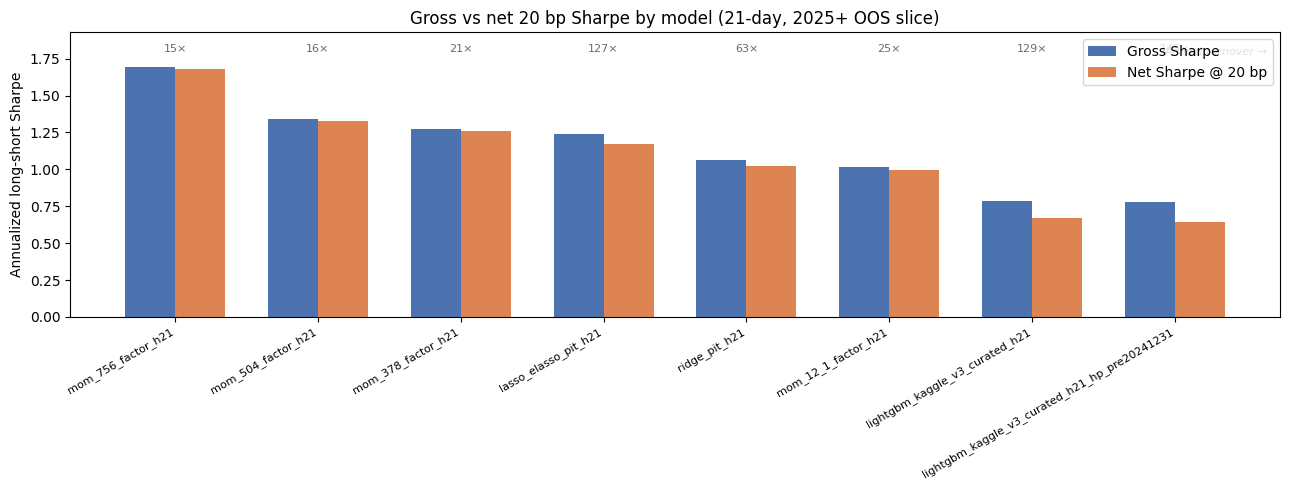

In [5]:
from price_model.eval.turnover import compare_models_costs

# Run net-of-cost decomposition on the same 2025+ joined frame from section 1.
# The model_id column is needed (compare_models_costs splits by model_id).
nc_table = compare_models_costs(
    joined,
    model_ids=HEADLINE_MODELS,
    top_frac=0.2,
    cost_bps=(3, 10, 20),
    horizon_days=21,
)
with pl.Config(tbl_width_chars=300, tbl_cols=20):
    print(nc_table)

# Build the bar chart: gross Sharpe vs net 20 bp Sharpe, with turnover annotation.
df_nc = nc_table.to_pandas().set_index('model_id')
df_nc = df_nc.sort_values('gross_long_short_sharpe', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(df_nc))
width = 0.35
ax.bar(x - width/2, df_nc['gross_long_short_sharpe'], width, label='Gross Sharpe', color='#4c72b0')
ax.bar(x + width/2, df_nc['after_cost_sharpe_20bp'], width, label='Net Sharpe @ 20 bp', color='#dd8452')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_nc.index, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Annualized long-short Sharpe')
ax.set_title('Gross vs net 20 bp Sharpe by model (21-day, 2025+ OOS slice)')
ax.legend(loc='upper right')

# Annotate each model with its annual turnover.
y_max = df_nc['gross_long_short_sharpe'].max() * 1.05
for i, (mid, row) in enumerate(df_nc.iterrows()):
    ax.text(i, y_max + 0.02, f'{row["annual_turnover"]:.0f}×',
            ha='center', fontsize=8, color='dimgray')
ax.set_ylim(top=y_max + 0.15)
ax.text(0.99, 0.95, 'Annual turnover →', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='dimgray', style='italic')
plt.tight_layout(); plt.show()


**Reading the chart:** the height-difference between the gross bar (blue) and net bar (orange) is the cost drag. Models whose two bars are almost identical retained nearly all their gross Sharpe — these are slow-turnover momentum factors. Models with a large gap lost a substantial fraction to costs — these are the higher-turnover L1 regression and LightGBM variants.

**Key observation:** look at the *ordering by net Sharpe* (orange bars) — it's different from the ordering by gross Sharpe (blue bars). The 36-month momentum factor, which trails the L1 regression on gross IC, *wins* on net Sharpe. This is the gross-vs-net inversion the README describes in Claim 1's deployment corollary.


## Next steps

- For static feature-level analysis (distributions, correlations, fit-on-train importance), see `notebooks/05_feature_exploration.ipynb`.
- For robustness checks on the headline (bootstrap CI, decile monotonicity, time-split partition), see `notebooks/03_headline_robustness.ipynb`.
- For survivorship-bias quantification on the legacy v2 panel, see `notebooks/00_pit_ablation_study.ipynb`.
- For classical EMH baselines (ARIMA / GARCH / GBM), see `notebooks/02_classical_timeseries.ipynb`.
